In [11]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv('../data/processed_data.csv')

In [13]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,...,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Indian,cuisine_Italian,cuisine_Thai,center_type_TYPE_B,center_type_TYPE_C
0,1499955,2020-01-02,55,1062,182.36,183.36,0,0,391,647,...,False,False,False,False,False,False,True,False,False,True
1,1351400,2020-01-02,24,1062,184.36,182.36,0,0,514,614,...,False,False,False,False,False,False,True,False,True,False
2,1057835,2020-01-02,11,1062,184.36,182.36,0,0,798,679,...,False,False,False,False,False,False,True,False,False,False
3,1231510,2020-01-02,83,1062,170.78,170.78,0,0,284,659,...,False,False,False,False,False,False,True,False,False,False
4,1402151,2020-01-02,32,1062,175.60,174.60,0,0,256,526,...,False,False,False,False,False,False,True,False,False,False


In [14]:
y = df['num_orders']

X = df.drop(['num_orders'], axis=1)

In [15]:
X = X.drop(['week'], axis=1)

In [16]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

In [17]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
lr_pred = lr_model.predict(X_test)

In [19]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

print("Linear Regression MAE:", lr_mae)

print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 131.85486726483038
Linear Regression RMSE: 209.484487765148


In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
rf_pred = rf_model.predict(X_test)

In [22]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 110.757238090023
Random Forest RMSE: 179.85847797894132


In [23]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [24]:
xgb_pred = xgb_model.predict(X_test)

In [25]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

print("XGBoost MAE:", xgb_mae)

print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 104.06986236572266
XGBoost RMSE: 180.11568548088752


In [26]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],

    'MAE': [
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    'RMSE': [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

results

,Model,MAE,RMSE
0,Linear Regression,131.854867,209.484488
1,Random Forest,110.757238,179.858478
2,XGBoost,104.069862,180.115685


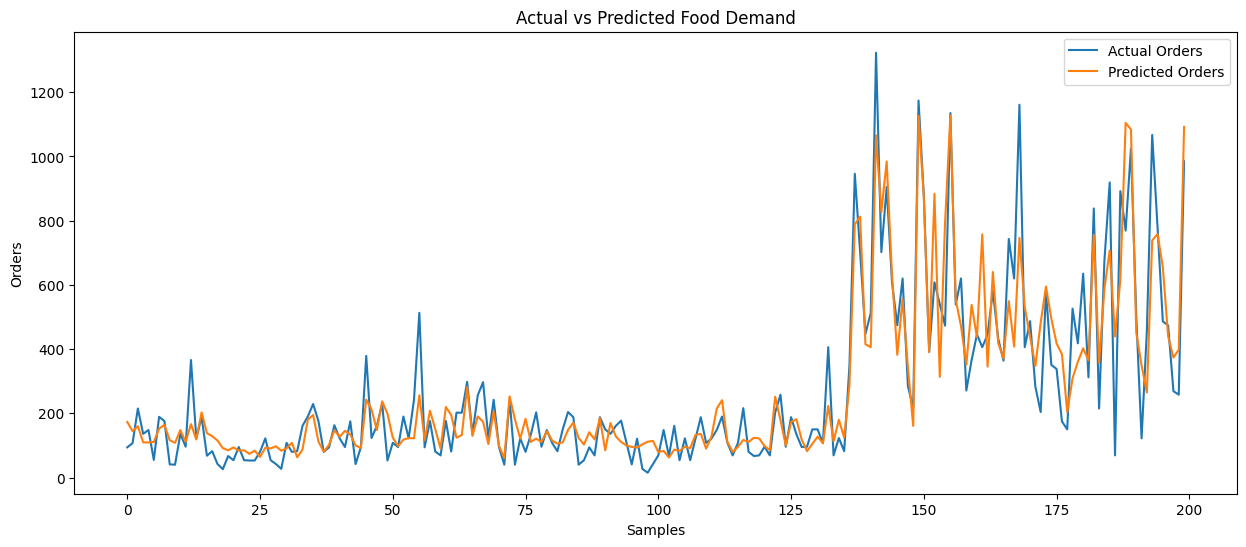

In [27]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:200],
    label='Actual Orders'
)

plt.plot(
    xgb_pred[:200],
    label='Predicted Orders'
)

plt.legend()

plt.title('Actual vs Predicted Food Demand')

plt.xlabel('Samples')

plt.ylabel('Orders')

plt.show()

In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [29]:
importance.head(10)

,Feature,Importance
17,rolling_mean_7,0.318790
9,op_area,0.087286
6,homepage_featured,0.064701
25,category_Rice Bowl,0.045192
8,region_code,0.041315
32,cuisine_Italian,0.036324
5,emailer_for_promotion,0.033038
20,category_Extras,0.028762
1,center_id,0.027589
7,city_code,0.026501


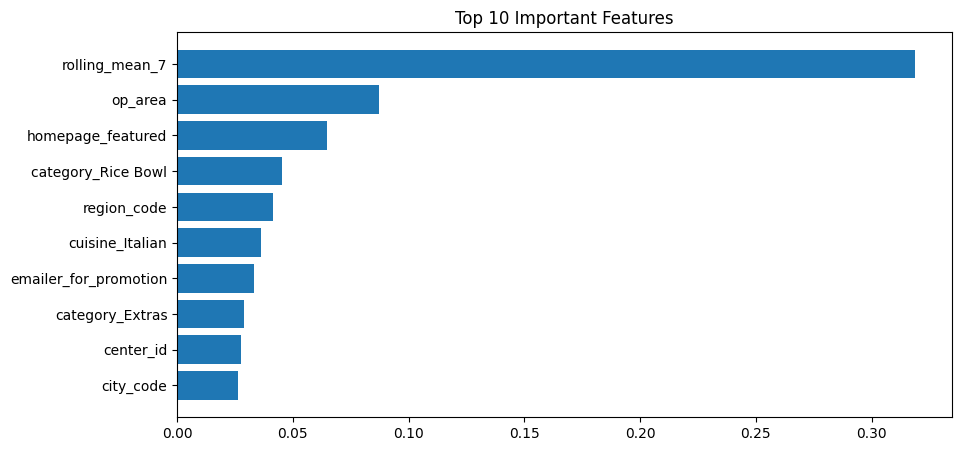

In [30]:
top_features = importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Important Features')

plt.gca().invert_yaxis()

plt.show()

In [35]:
import joblib

joblib.dump(
    xgb_model,
    '../models/xgboost_model.pkl'
)

['../models/xgboost_model.pkl']

In [36]:
results.to_csv(
    '../data/model_results.csv',
    index=False
)